# 13 - Sentetik Veri Augmentasyon Ablasyonu

---
## Bölüm 1: Hazırlık

In [1]:
import sys, os, json, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier
from sklearn.linear_model import LogisticRegression

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams['figure.dpi'] = 110

sys.path.insert(0, '..')
sys.path.insert(0, os.path.join('..', 'src'))
from synthetic_generator import SyntheticTelemetryGenerator
from feature_engineer import segment_raw_telemetry, extract_esa_features
from metrics import compute_metrics, BENCHMARK_METRICS

ESA_18 = ['mean', 'var', 'std', 'kurtosis', 'skew', 'n_peaks', 'duration', 'len',
          'gaps_squared', 'len_weighted', 'var_div_duration', 'var_div_len',
          'smooth10_n_peaks', 'smooth20_n_peaks', 'diff_peaks', 'diff2_peaks',
          'diff_var', 'diff2_var']


In [4]:
df = pd.read_csv('../data/raw/dataset.csv')
T = df[df['train'] == 1]; Psi = df[df['train'] == 0]
X_real = T[ESA_18].fillna(0).values;  y_real = T['anomaly'].values
X_psi  = Psi[ESA_18].fillna(0).values; y_psi  = Psi['anomaly'].values
print(f"Gerçek: {X_real.shape} ({y_real.mean():.1%} anomali)")
print(f"Gerçek: {X_psi.shape} ({y_psi.mean():.1%} anomali)")


Gerçek: (1594, 18) (20.1% anomali)
Gerçek: (529, 18) (21.4% anomali)


In [5]:
gen = SyntheticTelemetryGenerator(seed=2024)
raw = gen.generate_raw_stream(n_segments_hint=2500, anomaly_ratio=0.20)
syn_df = extract_esa_features(segment_raw_telemetry(raw, seed=2024))
X_syn = syn_df[ESA_18].fillna(0).values
y_syn = syn_df['anomaly'].values
print(f"\nSentetik havuz: {X_syn.shape} ({y_syn.mean():.1%} anomali)")


Ham akis uretildi: 376,417 ornek, 7 kanal, 41,504 anomali ornegi.
Segmentasyon tamamlandi: 2778 segment (581 anomali, %20.9), 376,417 satir.
  [200/2778] segment isleniyor...
  [400/2778] segment isleniyor...
  [600/2778] segment isleniyor...
  [800/2778] segment isleniyor...
  [1000/2778] segment isleniyor...
  [1200/2778] segment isleniyor...
  [1400/2778] segment isleniyor...
  [1600/2778] segment isleniyor...
  [1800/2778] segment isleniyor...
  [2000/2778] segment isleniyor...
  [2200/2778] segment isleniyor...
  [2400/2778] segment isleniyor...
  [2600/2778] segment isleniyor...
  [2778/2778] segment isleniyor...
Tamamlandi: 2778 segment, 18 ozellik cikarildi.

Sentetik havuz: (2778, 18) (20.9% anomali)


---
## Bölüm 2: Gerçek vs Sentetik Özellik Dağılımı

In [6]:
from scipy.stats import ks_2samp

ks_rows = []
for i, f in enumerate(ESA_18):
    ks = ks_2samp(X_real[:, i], X_syn[:, i]).statistic
    ks_rows.append({'Özellik': f, 'KS_mesafe': round(ks, 3)})
ks_df = pd.DataFrame(ks_rows).sort_values('KS_mesafe', ascending=False)
print(f"Ortalama KS mesafesi: {ks_df['KS_mesafe'].mean():.3f}  (0=özdeş dağılım, 1=ayrık)")
print(f"KS > 0.3 (belirgin sapma) olan özellik: {(ks_df['KS_mesafe'] > 0.3).sum()}/18")
display(ks_df.head(8).style.background_gradient(cmap='Reds', subset=['KS_mesafe']))


Ortalama KS mesafesi: 0.291  (0=özdeş dağılım, 1=ayrık)
KS > 0.3 (belirgin sapma) olan özellik: 9/18


,Özellik,KS_mesafe
5,n_peaks,0.520000
3,kurtosis,0.481000
17,diff2_var,0.463000
12,smooth10_n_peaks,0.386000
8,gaps_squared,0.364000
1,var,0.339000
2,std,0.339000
9,len_weighted,0.337000


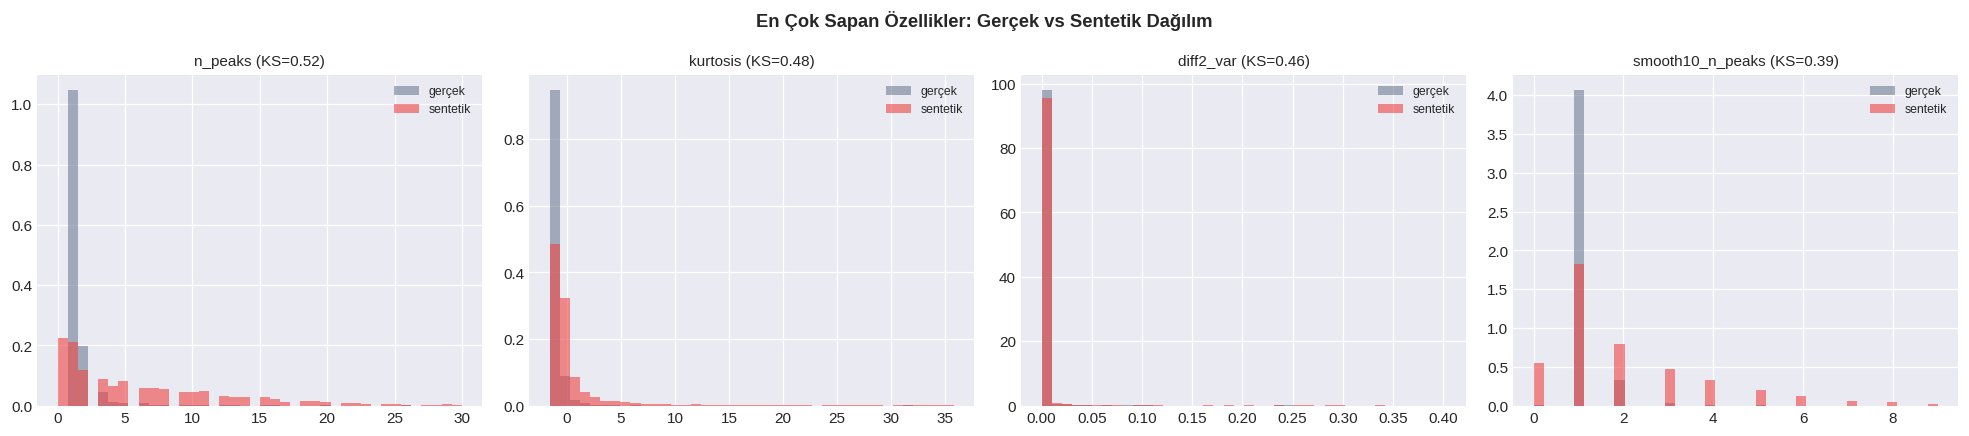

In [7]:
top_div = ks_df.head(4)['Özellik'].tolist()
fig, axes = plt.subplots(1, 4, figsize=(18, 4))
for ax, f in zip(axes, top_div):
    i = ESA_18.index(f)
    lo, hi = np.percentile(np.concatenate([X_real[:, i], X_syn[:, i]]), [1, 99])
    ax.hist(X_real[:, i], bins=40, range=(lo, hi), alpha=0.55, density=True,
            color='#64748B', label='gerçek')
    ax.hist(X_syn[:, i], bins=40, range=(lo, hi), alpha=0.6, density=True,
            color='#EF4444', label='sentetik')
    ax.set_title(f"{f} (KS={ks_df[ks_df['Özellik']==f]['KS_mesafe'].values[0]:.2f})", fontsize=10)
    ax.legend(fontsize=8)
plt.suptitle('En Çok Sapan Özellikler: Gerçek vs Sentetik Dağılım', fontsize=12, fontweight='bold')
plt.tight_layout(); plt.show()


---
## Bölüm 3: Deney A, Tam Veri Augmentasyonu

In [8]:
def eval_on_psi(X_tr, y_tr, scaler, model_ctor):
    model = model_ctor()
    model.fit(scaler.transform(X_tr), y_tr)
    prob = model.predict_proba(scaler.transform(X_psi))[:, 1]
    pred = (prob >= 0.5).astype(int)
    return compute_metrics(y_psi, pred, prob)

MODELS = {
    'RandomForest': lambda: RandomForestClassifier(n_estimators=200, random_state=42),
    'ExtraTrees':   lambda: ExtraTreesClassifier(n_estimators=200, random_state=42),
    'LogReg':       lambda: LogisticRegression(max_iter=1000),
}
AMOUNTS = [0, 250, 500, 1000, 2000]

scaler_full = StandardScaler().fit(X_real)
expA = []
for mname, ctor in MODELS.items():
    for n in AMOUNTS:
        if n == 0:
            Xtr, ytr = X_real, y_real
        else:
            Xtr = np.vstack([X_real, X_syn[:n]])
            ytr = np.concatenate([y_real, y_syn[:n]])
        m = eval_on_psi(Xtr, ytr, scaler_full, ctor)
        expA.append({'Model': mname, 'Sentetik': n, 'AUC_PR': m['AUC_PR'],
                     'F1': m['F1'], 'MCC': m['MCC']})
expA_df = pd.DataFrame(expA)
display(expA_df.pivot(index='Model', columns='Sentetik', values='AUC_PR')
        .style.background_gradient(cmap='RdYlGn', axis=1).format('{:.3f}'))


Sentetik,0,250,500,1000,2000
Model,,,,,
ExtraTrees,0.983,0.983,0.983,0.983,0.982
LogReg,0.927,0.915,0.910,0.910,0.873
RandomForest,0.967,0.971,0.970,0.971,0.970


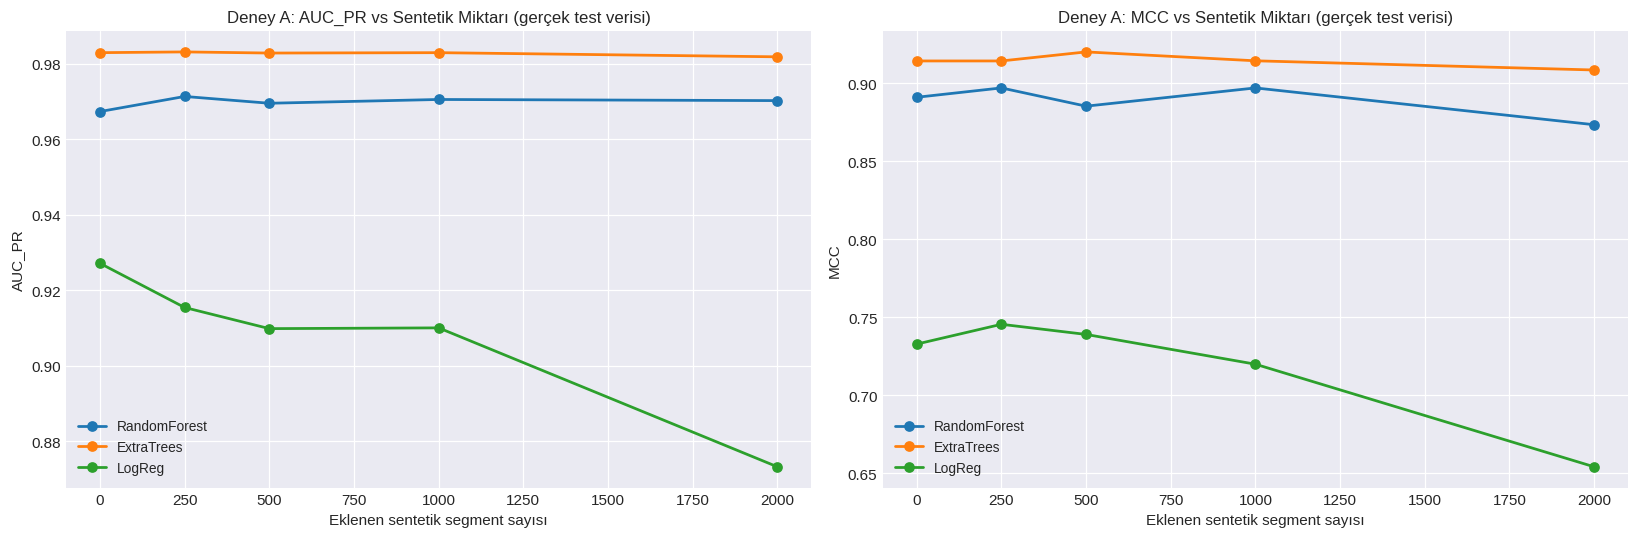

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
for metric, ax in zip(['AUC_PR', 'MCC'], axes):
    for mname in MODELS:
        sub = expA_df[expA_df['Model'] == mname]
        ax.plot(sub['Sentetik'], sub[metric], marker='o', lw=1.8, label=mname)
    ax.set_xlabel('Eklenen sentetik segment sayısı')
    ax.set_ylabel(metric)
    ax.set_title(f'Deney A: {metric} vs Sentetik Miktarı (gerçek test verisi)', fontsize=11)
    ax.legend(fontsize=9)
plt.tight_layout(); plt.show()


---
## Bölüm 4: Deney B, Az Veri Rejimi

In [10]:
rng = np.random.default_rng(0)
FRACTIONS = [0.15, 0.30, 0.50, 1.0]
N_SYN_FIXED = 1000
expB = []
for frac in FRACTIONS:
    k = max(20, int(frac * len(y_real)))
    idx = rng.choice(len(y_real), size=k, replace=False)
    Xsub, ysub = X_real[idx], y_real[idx]
    sc = StandardScaler().fit(Xsub)
    m0 = eval_on_psi(Xsub, ysub, sc, MODELS['RandomForest'])
    m1 = eval_on_psi(np.vstack([Xsub, X_syn[:N_SYN_FIXED]]),
                     np.concatenate([ysub, y_syn[:N_SYN_FIXED]]), sc, MODELS['RandomForest'])
    expB.append({'Gerçek %': int(frac*100), 'Gerçek N': k,
                 'AUC_PR (yalnız gerçek)': round(m0['AUC_PR'], 3),
                 'AUC_PR (+1000 sentetik)': round(m1['AUC_PR'], 3),
                 'ΔAUC_PR': round(m1['AUC_PR'] - m0['AUC_PR'], 3),
                 'ΔMCC': round(m1['MCC'] - m0['MCC'], 3)})
expB_df = pd.DataFrame(expB)
display(expB_df.style.background_gradient(cmap='RdYlGn', subset=['ΔAUC_PR', 'ΔMCC'],
                                          vmin=-0.1, vmax=0.1).format(
    {c: '{:.3f}' for c in expB_df.columns if 'AUC' in c or 'Δ' in c}))


,Gerçek %,Gerçek N,AUC_PR (yalnız gerçek),AUC_PR (+1000 sentetik),ΔAUC_PR,ΔMCC
0,15,239,0.948,0.935,-0.013,-0.073
1,30,478,0.955,0.951,-0.004,-0.007
2,50,797,0.960,0.968,0.008,-0.071
3,100,1594,0.969,0.971,0.002,-0.006


---
## Bölüm 5: Bulgular ve Yorum


In [11]:
base = expA_df[expA_df['Sentetik'] == 0].set_index('Model')['AUC_PR']
best_aug = expA_df[expA_df['Sentetik'] > 0].groupby('Model')['AUC_PR'].max()
print(f"Sentetik-gerçek ortalama KS dağılım mesafesi: {ks_df['KS_mesafe'].mean():.3f}\n")
print(f"{'Model':14s} {'Baseline':>9s} {'En iyi+sentetik':>16s} {'Δ':>8s}")
for m in MODELS:
    d = best_aug[m] - base[m]
    print(f"{m:14s} {base[m]:>9.3f} {best_aug[m]:>16.3f} {d:>+8.3f}")
helped = sum(1 for m in MODELS if best_aug[m] > base[m])
print(f"\nTam veride sentetik AUC_PR'yi artıran model: {helped}/{len(MODELS)}")
print(f"Az veri rejiminde ortalama ΔAUC_PR: {expB_df['ΔAUC_PR'].mean():+.3f}")


Sentetik-gerçek ortalama KS dağılım mesafesi: 0.291

Model           Baseline  En iyi+sentetik        Δ
RandomForest       0.967            0.971   +0.004
ExtraTrees         0.983            0.983   +0.000
LogReg             0.927            0.915   -0.012

Tam veride sentetik AUC_PR'yi artıran model: 2/3
Az veri rejiminde ortalama ΔAUC_PR: -0.002


---
## Bölüm 6: Kaydetme


In [12]:
os.makedirs('../reports/metrics', exist_ok=True)
expA_df.to_csv('../reports/metrics/ablation_synthetic_fulldata.csv', index=False)
expB_df.to_csv('../reports/metrics/ablation_synthetic_lowdata.csv', index=False)
ks_df.to_csv('../reports/metrics/synthetic_real_ks_distance.csv', index=False)